In [1]:
import gpt as g
import sys, os
import numpy as np

from scipy.linalg import expm
import time
import matplotlib.pyplot as plt
from gpt.qcd.gauge.smear import local_stout  
from gpt.ad import reverse as rad
from gpt.qcd.gauge.smear.differentiable import dft_diffeomorphism
import time

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x300000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [16]:
size = 4
grid = g.grid([size, size, size, size], g.double)
rng = g.random("t")

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)

U[0][0,0,0,0][:]

GPT :     254.660078 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.000306845 s


array([[ 0.76625215-0.17265836j,  0.17477135+0.25699139j,
        -0.01156183-0.53509201j],
       [-0.37464268-0.29244914j,  0.37631546+0.59590641j,
         0.52481561-0.04435278j],
       [-0.21139285-0.33537466j, -0.54663885-0.32844876j,
         0.38156065-0.53903223j]])

In [ ]:
"""
grid_cb = grid.checkerboarded(g.redblack)
one_cb = g.complex(grid_cb)
one_cb[:] = 1

masks = {}
for p in [g.even, g.odd]:
    m = g.complex(grid)
    m[:] = 0
    one_cb.checkerboard(p)
    g.set_checkerboard(m, one_cb)
    masks[p] = m
    
mask, imask = masks[g.odd], masks[g.odd.inv()] 

fm = g(mask + 1e-15 * imask)

fm[:][1]
"""

In [2]:
def trace_U(U):                                                      
    return sum(v for v in sum(u[:].real for u in g.eval(g.trace(U)))) / (4 * size**4 ) / 3.

In [4]:
num_steps = 1
def ftg(U, eps):
    global num_steps

    ##### dmuAmu ##############
    #B = U[0] -  g.adj(g.cshift(U[0], 0, -1))
    B = U[0] -  g.cshift(U[0], 0, -1)
    for mu in [1,2,3,]:
        #B += U[mu] -  g.adj(g.cshift(U[mu], mu, -1))
        B += U[mu] -  g.cshift(U[mu], mu, -1)

   #### masks for all even/odd sites ########
    """
    grid_cb = grid.checkerboarded(g.redblack)
    one_cb = g.complex(grid_cb)
    one_cb[:] = 1

    masks = {}
    for p in [g.even, g.odd]:
        m = g.complex(grid)
        m[:] = 0
        one_cb.checkerboard(p)
        g.set_checkerboard(m, one_cb)
        masks[p] = m
    
    if num_steps // 2 == 0:
        mask, imask = masks[g.odd], masks[g.odd.inv()] 
    else:
        mask, imask = masks[g.even], masks[g.even.inv()]
    
    num_steps += 1
    fm = g(mask + 1e-15 * imask)
    #fm = mask + 1e-15 * imask
    
    ###### apply masks ########
    #B *= fm # causes issues with action log det routine
    #B = g(B*fm)
    """
    
    # apply gtf 
    U_prime = []
    for mu in [0,1,2,3]:
        U_mu_prime = g(
                g.matrix.exp(  - eps * g.qcd.gauge.project.traceless_anti_hermitian(B) )  
                * U[mu] * g.matrix.exp(  + eps * g.qcd.gauge.project.traceless_anti_hermitian( g.cshift(B, mu, +1) ) ) 
        )
        U_prime.append(U_mu_prime)
    
    return U_prime


In [5]:
size = 4
grid = g.grid([size, size, size, size], g.double)
rng = g.random("t")

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)


GPT :       2.223021 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.00216484 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [6]:
for u in U:
    print(u)

lattice(ot_matrix_su_n_fundamental_group(3),double)
[0,0,0,0]	S {S {M<3>{{(0.766252,-0.172658),(0.174771,0.256991),(-0.0115618,-0.535092)}
		{(-0.374643,-0.292449),(0.376315,0.595906),(0.524816,-0.0443528)}
		{(-0.211393,-0.335375),(-0.546639,-0.328449),(0.381561,-0.539032)}}}}
[1,0,0,0]	S {S {M<3>{{(0.310649,-0.549124),(0.642753,-0.113876),(-0.413998,-0.0668286)}
		{(-0.479492,0.167673),(0.58714,0.467892),(0.136146,0.399726)}
		{(0.344834,-0.474365),(-0.0520788,0.0867854),(0.728426,0.339438)}}}}
[2,0,0,0]	S {S {M<3>{{(0.782897,0.354285),(-0.13267,-0.095884),(-0.235511,-0.423431)}
		{(0.064549,-0.111433),(0.756935,-0.630744),(-0.112219,-0.00580712)}
		{(0.459675,-0.183493),(0.0234124,-0.0432155),(0.835314,0.234232)}}}}
[3,0,0,0]	S {S {M<3>{{(0.362623,0.394449),(0.493291,-0.600877),(0.329378,0.00599145)}
		{(-0.463615,-0.650099),(0.252734,-0.414863),(0.147725,0.323457)}
		{(0.181499,-0.205927),(-0.0747908,0.392469),(0.874615,0.00863602)}}}}
[0,1,0,0]	S {S {M<3>{{(0.369031,0.141973),(-0.

In [18]:
def ft0(U):
    return ftg(U, eps = -5e-2)
    
#dft = dft_diffeomorphism(U, ft0)
fr = g.algorithms.optimize.fletcher_reeves
ls2 = g.algorithms.optimize.line_search_quadratic

dft = g.qcd.gauge.smear.differentiable_field_transformation(
    U,
    ft0,
    #g.algorithms.inverter.fgmres(eps=1e-15, maxiter=30, restartlen=10),
    #g.algorithms.inverter.fgmres(eps=1e-15, maxiter=30, restartlen=10),
    g.algorithms.inverter.fgcr(eps=1e-13, maxiter=100, restartlen=10),
    g.algorithms.inverter.fgcr(eps=1e-13, maxiter=100, restartlen=10),
    g.algorithms.optimize.non_linear_cg(
        maxiter=100, eps=1e-15, step=1e-1, line_search=ls2, beta=fr
    ),
)

dfm = dft.diffeomorphism()
ald = dft.action_log_det_jacobian()

In [19]:
# FT

Vgf = dft.inverse(U)

# conjugate momenta
U_mom = g.group.cartesian(Vgf)
#U_mom = g.group.cartesian(U)

action_gauge_mom = g.qcd.scalar.action.mass_term()
action_gauge = g.qcd.gauge.action.wilson(10.0)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()

pure_gauge = True

"""
def transform(aa, s, i):
    aa_transformed = aa[i].transformed(s, indices=list(range(len(U))))
    aa_orig = aa[i]
    def draw(fields, rng, *extra):
        sfields = s(fields[0:len(U)]) + fields[len(U):]
        x = aa_orig.draw(sfields, rng, *extra)
        return x
    aa_transformed.draw = draw
    aa[i] = aa_transformed
"""

a_log_det = dft.action_log_det_jacobian()

GPT :     833.347473 s : non_linear_cg: iteration 0: f(x) = 4.216594582974055e+00, |df|/sqrt(dof) = 7.784643e-02, beta = 0, step = 0.6538799689758568
GPT :     835.003216 s : non_linear_cg: iteration 10: f(x) = 2.296633800722229e-11, |df|/sqrt(dof) = 1.290811e-07, beta = 0.057882805094522254, step = 0.7694043628386036
GPT :     836.729851 s : non_linear_cg: iteration 20: f(x) = 1.178890360065091e-22, |df|/sqrt(dof) = 3.070494e-13, beta = 0.07479140879065062, step = 0.7695634807298541
GPT :     837.574581 s : non_linear_cg: converged in 26 iterations: f(x) = 2.749762746053898e-25, |df|/sqrt(dof) = 4.416631e-16


In [20]:
mom = [g.group.cartesian(v) for v in Vgf]
mom_prime = g.copy(mom)
rng.normal_element(mom_prime)

mom2 = dfm.jacobian(Vgf, U, mom_prime) # this appears to have fixed it???
ald = a_log_det(Vgf + mom2) # don't know if this is the correct log det!!!
g.message("Action log det jac:", ald)

GPT :     840.594859 s : fgcr: converged in 21 iterations;  computed squared residual 1.020974e-23 / 4.531055e-23;  true squared residual 1.020752e-23 / 4.531055e-23
GPT :     841.985451 s : fgcr: converged in 21 iterations;  computed squared residual 9.361535e-24 / 4.044704e-23;  true squared residual 9.361609e-24 / 4.044704e-23
GPT :     841.992344 s : Action log det jac: 4044.7040684980016


In [21]:
def hamiltonian(draw):
    global mom2
    if draw:
        rng.normal_element(U_mom)
        
        mom = [g.group.cartesian(v) for v in Vgf]
        #mom = [g.group.cartesian(u) for u in U]
        mom_prime = g.copy(mom)
        rng.normal_element(mom_prime)

        W = dfm(Vgf)
        mom2 = dfm.jacobian(Vgf, W, mom_prime) # this appears to have fixed it???
        ald = a_log_det(Vgf + mom2)
        
        
        #s = action_gauge(U)

        
        s = action_gauge(Vgf)

        
        h = s + action_gauge_mom(U_mom) + ald
        #h = s + action_gauge_mom(U_mom)

    else:
        
        ald = a_log_det(Vgf + mom2)
        s = action_gauge(Vgf)
        #s = action_gauge(U)

        h = s + action_gauge_mom(U_mom) + ald

    g.message("Gluonic action", s)
    g.message("Log-det action", ald)
        
    return h, s


In [22]:
hamiltonian(True)

GPT :     847.971245 s : fgcr: converged in 21 iterations;  computed squared residual 1.126881e-23 / 4.701117e-23;  true squared residual 1.127041e-23 / 4.701117e-23
GPT :     849.361352 s : fgcr: converged in 21 iterations;  computed squared residual 7.922689e-24 / 4.209918e-23;  true squared residual 7.922034e-24 / 4.209918e-23
GPT :     849.362895 s : Gluonic action 14818.207957711416
GPT :     849.363115 s : Log-det action 4209.918274853183


(np.float64(23112.294505981336), np.float64(14818.207957711416))

In [23]:
def log_det_force():
    #g.message("Compute log_det force")
    x = log(lambda: a_log_det.gradient(Vgf + mom2, Vgf), "log det")()
    #g.message("second level force complete")
    return x

def gauge_force():
    #g.message("Compute gauge force")
    x = log(lambda: action_gauge.gradient(Vgf, Vgf), "gauge")()
    return x
    
#def gauge_force222():
#    return gauge_force() + log_det_force()

In [24]:
iq = sympl.update_q(
    Vgf, log(lambda: action_gauge_mom.gradient(U_mom, U_mom), "gauge_mom")
)

ip_gauge = sympl.update_p(U_mom, gauge_force)

ip_log_det = sympl.update_p(U_mom, log_det_force)

# integrator
mdint = sympl.leap_frog(1, ip_log_det, sympl.leap_frog(3, ip_gauge, iq))


g.message(f"Integration scheme:\n{mdint}")

tau = 1.0
#nsteps = 20



GPT :     853.149978 s : Integration scheme:
                       : leap_frog(1, P, leap_frog(3, P, Q))
                       :   P(0.5, 0)
                       :   P(0.16666666666666666, 0)
                       :   Q(0.3333333333333333, 0)
                       :   P(0.3333333333333333, 0)
                       :   Q(0.3333333333333333, 0)
                       :   P(0.3333333333333333, 0)
                       :   Q(0.3333333333333333, 0)
                       :   P(0.16666666666666666, 0)
                       :   P(0.5, 0)


In [25]:
no_accept_reject = False

def hmc(tau):
    accrej = metro(Vgf)
    #accrej = metro(U)
    g.message("After metro")

    h0, s0 = hamiltonian(True)
    
    #its0 = nsteps - 1
    nsteps = 13
    for i in range(nsteps):
        mdint(tau/nsteps)

    g.message("After mdint(tau)")
    h1, s1 = hamiltonian(False)
    g.message("After H(false)")
    
    if no_accept_reject:
        return [True, s1 - s0, h1 - h0]
    else:
        return [accrej(h1, h0), s1 - s0, h1 - h0]
   

In [26]:
hmc(1.)

GPT :     865.491216 s : After metro
GPT :     868.147924 s : fgcr: converged in 21 iterations;  computed squared residual 1.085944e-23 / 4.508757e-23;  true squared residual 1.086155e-23 / 4.508757e-23
GPT :     869.529867 s : fgcr: converged in 21 iterations;  computed squared residual 7.962952e-24 / 4.039413e-23;  true squared residual 7.962658e-24 / 4.039413e-23
GPT :     869.530974 s : Gluonic action 14818.207957711416
GPT :     869.531174 s : Log-det action 4039.4126558359226
GPT :     872.075000 s : fgcr: converged in 21 iterations;  computed squared residual 1.085944e-23 / 4.508757e-23;  true squared residual 1.086155e-23 / 4.508757e-23
GPT :     873.456319 s : fgcr: converged in 21 iterations;  computed squared residual 7.962952e-24 / 4.039413e-23;  true squared residual 7.962658e-24 / 4.039413e-23
GPT :     876.666259 s : fgcr: converged in 21 iterations;  computed squared residual 1.080765e-23 / 4.508757e-23;  true squared residual 1.080810e-23 / 4.508757e-23
GPT :     878.0

[True, np.float64(-4259.969194472051), np.float64(-2.3786008010356454)]

In [27]:
accept, total = 0, 0

plaq_measurements = []
trace_measurements = []

for it in range(20):
    #pure_gauge = it < 10
    no_accept_reject = it < 10
    g.message(pure_gauge, no_accept_reject)

    a, dS, dH = hmc(tau)
    accept += a
    total += 1


    #Uft = U
    #for s in reversed(sm):
    #    Uft = s(Uft)
        
    plaq = g.qcd.gauge.plaquette(Vgf)
    plaq_measurements.append(plaq)
    trace_measurements.append(trace_U(Vgf))
    
    g.message(f"HMC plaq = {plaq}, dS = {dS}, dH = {dH}, acceptance = {accept/total}")
    g.message(f"Timing:\n{log.time}")
    g.message(f"TRAJECTORY NUM {it}")

GPT :    2035.454088 s : True True
GPT :    2035.455802 s : After metro
GPT :    2038.573102 s : fgcr: converged in 25 iterations;  computed squared residual 1.975188e-23 / 4.501697e-23;  true squared residual 1.974914e-23 / 4.501697e-23
GPT :    2040.168108 s : fgcr: converged in 25 iterations;  computed squared residual 2.706965e-23 / 4.161249e-23;  true squared residual 2.706919e-23 / 4.161249e-23
GPT :    2040.169541 s : Gluonic action 10558.238763239366
GPT :    2040.169744 s : Log-det action 4161.249032691639
GPT :    2043.158147 s : fgcr: converged in 25 iterations;  computed squared residual 1.975188e-23 / 4.501697e-23;  true squared residual 1.974914e-23 / 4.501697e-23
GPT :    2044.775555 s : fgcr: converged in 25 iterations;  computed squared residual 2.706965e-23 / 4.161249e-23;  true squared residual 2.706919e-23 / 4.161249e-23
GPT :    2048.413145 s : fgcr: converged in 25 iterations;  computed squared residual 2.543882e-23 / 4.501697e-23;  true squared residual 2.543892e

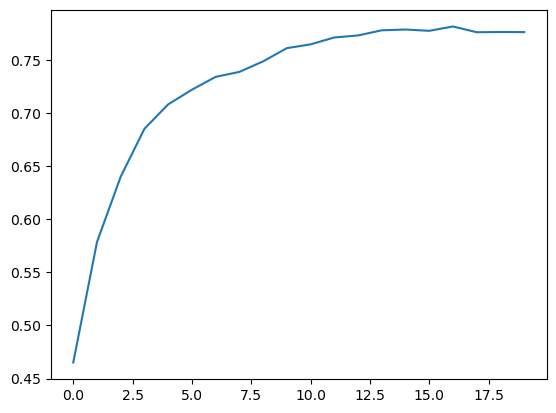

In [28]:
plt.plot(plaq_measurements)

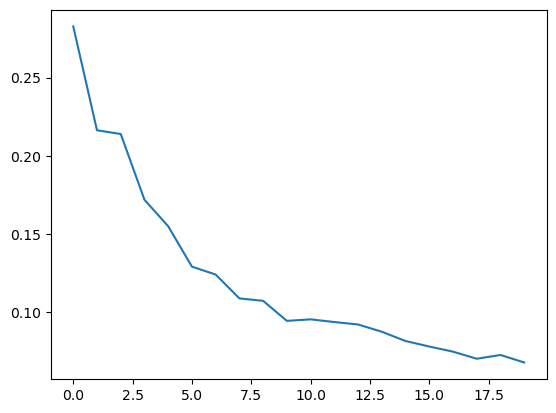

In [29]:
plt.plot(trace_measurements)

In [47]:
meas = np.array(plaq_measurements[20:])

print(f"Mean plaq = {np.mean(meas)}, std = {np.std(meas)}")

Mean plaq = 0.7793838463472568, std = 0.0038725579630290697


In [ ]:
#Mean plaq = 0.7845633668169114, std = 0.003990982543130267

In [31]:
a = log_det_force()
b = gauge_force()

GPT :    7390.590322 s : fgcr: converged in 22 iterations;  computed squared residual 4.216025e-23 / 4.246278e-23;  true squared residual 4.215828e-23 / 4.246278e-23
GPT :    7392.038653 s : fgcr: converged in 22 iterations;  computed squared residual 3.919969e-23 / 4.130587e-23;  true squared residual 3.920425e-23 / 4.130587e-23


In [45]:
a[0][:][7]

array([[-0.05672697+0.j        , -0.02946311-0.05599906j,
        -0.08468043+0.00095936j],
       [-0.02946311+0.05599906j,  0.14251587+0.j        ,
         0.00068125+0.07802643j],
       [-0.08468043-0.00095936j,  0.00068125-0.07802643j,
        -0.0857889 +0.j        ]])

In [46]:
b[0][:][7]

array([[ 0.12052967+0.j        , -2.84043449+0.64674957j,
         0.93928084+1.34633497j],
       [-2.84043449-0.64674957j, -0.08066929+0.j        ,
         1.32386586+1.40513725j],
       [ 0.93928084-1.34633497j,  1.32386586-1.40513725j,
        -0.03986038+0.j        ]])